## Tasmanian Conditioning
This notebook exists to process hand-scored data from CCNL planarian conditioning projects that follow the protocls described in [James et al. (2025)](https://drive.google.com/file/d/1QFx8QHdXEkjAiJImBWZC_EdjRTzK_7hg/view?usp=drive_link). The data can be found [here](https://docs.google.com/spreadsheets/d/1M-xnRcIi3IS6-G30y5ylytBrqeMi3pINym3OKOTZn3c/edit?usp=sharing). This notebook is geared for reporting sums on a day.

I'm visually comparing my data to Sage's. It'll be plotting essentially the same structure of lines on a graph, color coded depending on whether they came from Sage or my data (manually scored turns and contractions per video).

## Import packages and set filepaths.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Define save path
SAVE_PATH = "/Users/zacharykelso/Desktop/"   # Enter path for where graphs will be saved.

# SCORER CONFIGURATION DICTIONARY
# All scorers should have a "profile" here; specify where their CSV is, the style of their lines on the graph, etc.

SCORER_CONFIG = {
    'Zach': {
        'csv_path': "/Users/zacharykelso/Desktop/Zach_Tasmdata_Tidy.csv",
        'enabled': True,            # Controls if the data will attempt to be loaded
        'label_name': 'Zach',       # Display name in legend
        'tc_color': 'deeppink',     # The style is color = identity and solid/dashed = TC/TP 
        'tc_linestyle': '-',        # Solid line
        'tp_color': 'deeppink',      
        'tp_linestyle': '--',       # Dashed line
        'marker': 'o',              # Circle marker
        'markersize': 8,
        'linewidth': 2,
        'alpha': 1.0
    },
    'Zach_unblind': {
        'csv_path': "/Users/zacharykelso/Desktop/Zach_Tasmdata_Tidy_unblind.csv",
        'enabled': False,
        'label_name': 'Zach (Unblind)',
        'tc_color': 'lightseagreen',      
        'tc_linestyle': '-',        
        'tp_color': 'lightseagreen',      
        'tp_linestyle': '--',      
        'marker': 'o',             
        'markersize': 8,
        'linewidth': 2,
        'alpha': 0.7                # Slightly transparent to distinguish from blind scoring
    },
    'Sage': {
        'csv_path': "/Users/zacharykelso/Desktop/Sage_Tasmdata_Tidy.csv",
        'enabled': True,
        'label_name': 'Sage',
        'tc_color': 'teal',        
        'tc_linestyle': '-',      
        'tp_color': 'teal',        
        'tp_linestyle': '--',       
        'marker': 's',              
        'markersize': 8,
        'linewidth': 2,
        'alpha': 1.0
    },
    'Fionn': {
        'csv_path': "/Users/zacharykelso/Desktop/Fionn_Tasmdata_Tidy.csv",
        'enabled': True,
        'label_name': 'Fionn',
        'tc_color': 'orange',     
        'tc_linestyle': '-',      
        'tp_color': 'orange',      
        'tp_linestyle': '--',    
        'marker': '^',             
        'markersize': 8,
        'linewidth': 2,
        'alpha': 1.0
    },
    'Sayed': {
        'csv_path': "/Users/zacharykelso/Desktop/Sayed_Tasmdata_Tidy.csv",
        'enabled': False,           # Do not yet have his data, so do not attempt to load.
        'label_name': 'Sayed',
        'tc_color': '#16a085',      
        'tc_linestyle': '-',        
        'tp_color': '#d35400',     
        'tp_linestyle': '--',       
        'marker': 'D',             
        'markersize': 7,
        'linewidth': 2,
        'alpha': 1.0
    }
}

# Load dataframes from csv for each scorere that is enabled
dfs = {}
for scorer, config in SCORER_CONFIG.items():
    if config['enabled']:
        try:
            dfs[scorer] = pd.read_csv(config['csv_path'])
            print(f"Loaded data for {scorer}")
        except FileNotFoundError:
            print(f"Warning: Could not find CSV for {scorer} at {config['csv_path']}")
        except Exception as e:
            print(f"Error loading {scorer}: {e}, and this wasn't just because the path wasn't found.")

# Report unique runs and troupes; should be same for everyone.
print("\n" + "="*60)
print("DATA SUMMARY")
print("="*60)

for scorer in dfs.keys():
    print(f"\n{scorer}'s data:")
    df = dfs[scorer]
    unique_runs = df['Run'].nunique()
    unique_troupes = df['Troupe'].nunique()
    print(f"\tUnique troupes: {sorted(df['Troupe'].unique())}")
    print(f"\tNumber of unique runs: {unique_runs}")
    print(f"\tNumber of unique troupes: {unique_troupes}")
    print(f"\tTroupes and runs agree? {unique_runs / unique_troupes == 8}.")

print("="*60 + "\n")

Loaded data for Zach
Loaded data for Sage
Loaded data for Fionn

DATA SUMMARY

Zach's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.

Sage's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.

Fionn's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.



## Analyze CSV and turn it into workable Numpy arrays.

In [74]:
# This function will take the data of the scoring sheets and extract means of scores across troupes, days, etc. 
def analyze_raw_counts(df, troupes=None, days=None, verbose=True):
    """
    Process behavioral data and create summary dataframe.
    
    Parameters:
    df (pandas.DataFrame): The dataframe to analyze
    troupes (list): List of troupe names to include. If None, includes all troupes. Valid troupes are TC-6, TC-7, TP-3, and TP-4. 
    days (list): List of day numbers to include. If None, includes all days. Valid days are 1 and 4 at the moment.
    verbose (bool): If True, print debugging information.
    
    Returns:
    pandas.DataFrame: Summary dataframe with columns Troupe, Worm, Day, CRturn, CRcon, UCRturn, UCRcon, UCRcombined, CRcombined
                     Sorted by Troupe, then Worm, then Day
    """

    # Create behavioral columns off of Worm numbers and response behavior type. We will make sure these are numeric so that summing operations work.
    behavioral_columns = []
    for behavior in ['CRturn', 'CRcon', 'UCRturn', 'UCRcon']:
        for worm in range(1, 7):     # Note that range cuts off the final value, so this is 1-6
            col_name = f"{behavior}_W{worm}"
            behavioral_columns.append(col_name)
    
    # Convert behavioral columns to numeric, replacing any non-numeric values with 0
    df_numeric = df.copy()
    for col in behavioral_columns:
        if col in df_numeric.columns:
            df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce').fillna(0) # Uses Pandas to force numeric, fill 0 if needed
    
    if verbose:
        print("Sample of data types after conversion:")
        print(df_numeric[behavioral_columns[:4]].dtypes)
    
    # Use all troupes and days if not specified
    if troupes is None:
        troupes = df_numeric['Troupe'].unique()
    if days is None:
        days = df_numeric['Day'].unique()
    
    if verbose:
        print(f"\nLooking for troupes: {troupes}")
        print(f"Looking for days: {days}")
    
    # Filter dataframe based on specified troupes and days
    filtered_df = df_numeric[df_numeric['Troupe'].isin(troupes) & df_numeric['Day'].isin(days)].copy()
    
    if verbose:
        print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    # Initialize list to store results
    results = []
    
    # Process each troupe/day combination
    for troupe in troupes:
        for day in days:
            # Get data for this troupe/day combination
            subset = filtered_df[(filtered_df['Troupe'] == troupe) & (filtered_df['Day'] == day)]
            
            if len(subset) == 0:
                if verbose:
                    print(f"No data found for Troupe: {troupe}, Day: {day}")
                continue
            
            if verbose:
                print(f"Processing Troupe: {troupe}, Day: {day} ({len(subset)} rows)")
                
            # Process each worm (W1 through W6)
            for worm_num in range(1, 7):
                worm_id = f"W{worm_num}"
                
                # Sum scores for each behavior type for this worm (now properly numeric)
                crturn_sum = subset[f'CRturn_{worm_id}'].sum()
                crcon_sum = subset[f'CRcon_{worm_id}'].sum()
                ucrturn_sum = subset[f'UCRturn_{worm_id}'].sum()
                ucrcon_sum = subset[f'UCRcon_{worm_id}'].sum()
                
                # Calculate combined values
                ucrcombined_sum = ucrcon_sum + ucrturn_sum
                crcombined_sum = crcon_sum + crturn_sum
                
                # Add row to results
                results.append({
                    'Troupe': troupe,
                    'Worm': worm_id,
                    'Day': day,
                    'CRturn': crturn_sum,
                    'CRcon': crcon_sum,
                    'UCRturn': ucrturn_sum,
                    'UCRcon': ucrcon_sum,
                    'UCRcombined': ucrcombined_sum,
                    'CRcombined': crcombined_sum
                })
    
    # Create summary dataframe
    summary_df = pd.DataFrame(results)
    
    # Sort the dataframe by Troupe, then Worm, then Day
    if len(summary_df) > 0:
        # Create a custom sort key for worms to ensure W1, W2, ..., W6 order
        summary_df['Worm_sort'] = summary_df['Worm'].str.extract('(\d+)').astype(int)
        
        # Sort by Troupe, then Worm_sort (numeric), then Day
        summary_df = summary_df.sort_values(['Troupe', 'Worm_sort', 'Day']).reset_index(drop=True)
        
        # Drop the temporary sorting column
        summary_df = summary_df.drop('Worm_sort', axis=1)
    
    if verbose:
        print(f"\nFinal summary dataframe shape: {summary_df.shape}")
        if len(summary_df) > 0:
            print("Data is now sorted by: Troupe → Worm → Day")
    
    return summary_df

## Define function to create results table

In [75]:
# Summary table, not used to create graphs, just for our sight.
def create_behavior_summary_table(scorer, tc_troupes=None, tp_troupes=None, 
                                 behaviors=['CRturn'], days=[1, 4], error_type='SEM'):
    """
    Creates a summary statistics table for behavioral data across specified days.
    Separates TC and TP groups in the output.
    
    Parameters:
    scorer (str): Name of the scorer (e.g., 'Zach', 'Sage', 'Fionn') - MUST already exist in dfs dictionary and be enabled
    tc_troupes (list or None): List of TC troupe names to analyze
    tp_troupes (list or None): List of TP troupe names to analyze
    behaviors (str or list): Single behavior or list of behaviors to analyze (CRturn and CRcon)
    days (list): List of days to include in analysis (1 and 4) 
    error_type (str): Error type to calculate: 'SEM' or '95CI' (default: 'SEM')
    
    Returns:
    pandas.DataFrame: Table with columns [Scorer, Group, Behavior, Day, Mean, SEM, Error_Value, N, Std]
    """
    
    # Import required for 95% CI calculation
    from scipy import stats
    
    # Validate scorer exists
    if scorer not in dfs:
        raise ValueError(f"Scorer '{scorer}' not found. Available scorers: {list(dfs.keys())}")
    
    # Get the dataframe for this scorer
    df = dfs[scorer]
    
    # Handle single behavior input
    if isinstance(behaviors, str):
        behavior_list = [behaviors]
    else:
        behavior_list = behaviors
    
    # Validate error_type parameter
    if error_type.upper() not in ['SEM', '95CI', 'CI']:
        raise ValueError("error_type must be 'SEM' or '95CI'")
    
    # Collect results
    results = []
    
    # Process TC troupes if provided
    if tc_troupes is not None:
        if isinstance(tc_troupes, str):
            tc_troupes = [tc_troupes]
        
        filtered_df = df[df['Troupe'].isin(tc_troupes) & df['Day'].isin(days)].copy()
        
        if not filtered_df.empty:
            for behavior in behavior_list:
                behavioral_columns = [f"{behavior}_W{worm}" for worm in range(1, 7)]
                
                # Convert to numeric
                for col in behavioral_columns:
                    if col in filtered_df.columns:
                        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
                
                for day in sorted(days):
                    day_data = filtered_df[filtered_df['Day'] == day]
                    
                    if day_data.empty:
                        continue
                    
                    # Collect all values for this behavior/day combination
                    all_values = []
                    for col in behavioral_columns:
                        if col in day_data.columns:
                            values = day_data[col].dropna()
                            all_values.extend(values.tolist())
                    
                    if all_values:
                        mean_val = np.mean(all_values)
                        sem_val = np.std(all_values, ddof=1) / np.sqrt(len(all_values))
                        std_val = np.std(all_values, ddof=1)
                        n_val = len(all_values)
                        
                        # Calculate error based on error_type parameter
                        if error_type.upper() == 'SEM':
                            error_val = sem_val
                            error_label = 'SEM_Error'
                        elif error_type.upper() == '95CI' or error_type.upper() == 'CI':
                            t_critical = stats.t.ppf(0.975, df=n_val-1)
                            error_val = t_critical * sem_val
                            error_label = '95% CI'
                        
                        results.append({
                            'Scorer': scorer,
                            'Group': 'TC',
                            'Behavior': behavior,
                            'Day': day,
                            'Mean': round(mean_val, 2),
                            'SEM': round(sem_val, 3),
                            f'{error_label}': round(error_val, 3),
                            'N': n_val,
                            'Std': round(std_val, 2)
                        })
    
    # Process TP troupes if provided
    if tp_troupes is not None:
        if isinstance(tp_troupes, str):
            tp_troupes = [tp_troupes]
        
        filtered_df = df[df['Troupe'].isin(tp_troupes) & df['Day'].isin(days)].copy()
        
        if not filtered_df.empty:
            for behavior in behavior_list:
                behavioral_columns = [f"{behavior}_W{worm}" for worm in range(1, 7)]
                
                # Convert to numeric
                for col in behavioral_columns:
                    if col in filtered_df.columns:
                        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
                
                for day in sorted(days):
                    day_data = filtered_df[filtered_df['Day'] == day]
                    
                    if day_data.empty:
                        continue
                    
                    # Collect all values for this behavior/day combination
                    all_values = []
                    for col in behavioral_columns:
                        if col in day_data.columns:
                            values = day_data[col].dropna()
                            all_values.extend(values.tolist())
                    
                    if all_values:
                        mean_val = np.mean(all_values)
                        sem_val = np.std(all_values, ddof=1) / np.sqrt(len(all_values))
                        std_val = np.std(all_values, ddof=1)
                        n_val = len(all_values)
                        
                        # Calculate error based on error_type parameter
                        if error_type.upper() == 'SEM':
                            error_val = sem_val
                            error_label = 'SEM_Error'
                        elif error_type.upper() == '95CI' or error_type.upper() == 'CI':
                            t_critical = stats.t.ppf(0.975, df=n_val-1)
                            error_val = t_critical * sem_val
                            error_label = '95% CI'
                        
                        results.append({
                            'Scorer': scorer,
                            'Group': 'TP',
                            'Behavior': behavior,
                            'Day': day,
                            'Mean': round(mean_val, 2),
                            'SEM': round(sem_val, 3),
                            f'{error_label}': round(error_val, 3),
                            'N': n_val,
                            'Std': round(std_val, 2)
                        })
    
    # Create and sort DataFrame
    summary_df = pd.DataFrame(results)
    if not summary_df.empty:
        summary_df = summary_df.sort_values(['Behavior', 'Group', 'Day']).reset_index(drop=True)
    
    return summary_df

## Define graphing function.

In [76]:
# The colors for lines in these graphs are determined in the scorere dictionaries in the first cell of this notebook. 

def create_day_comparison_lines(tc_troupes, tp_troupes, 
                                scorers=None,
                                behaviors=['CRturn'], days=[1, 4], 
                                figsize=(8, 6), SAVE=False, filename="", 
                                ylim=None, turn_ylim=None, con_ylim=None,
                                marker_size=None, line_width=None, show_legend=True,
                                error_type='SEM'):
    """
    Creates line plots comparing TC and TP troupes across days for specified scorers.
    Each scorer has unique colors, with TC as solid lines and TP as dashed lines.
    
    Parameters:
    tc_troupes (list): List of TC troupe names
    tp_troupes (list): List of TP troupe names
    scorers (list or None): List of scorer names to plot. If None, uses all available scorers in dfs.
                           Example: ['Zach', 'Sage'] or ['Zach', 'Fionn', 'Sage']
    behaviors (str or list): Single behavior or list of behaviors to analyze
    days (list): List of days to compare (default: [1, 4])
    figsize (tuple): Figure size (default: (8, 6))
    SAVE (bool): If True, saves the plot. If False, displays it
    filename (str): Custom filename for saving. If empty, auto-generates
    ylim (float or None): General maximum Y-axis limit. If None, uses behavior-specific limits
    turn_ylim (float or None): Maximum Y-axis limit for turning behaviors
    con_ylim (float or None): Maximum Y-axis limit for contraction behaviors
    marker_size (int or None): Size of markers. If None, uses value from SCORER_CONFIG
    line_width (int or None): Width of lines. If None, uses value from SCORER_CONFIG
    show_legend (bool): Whether to show legend (default: True)
    error_type (str): Error bar type: 'SEM' or '95CI' (default: 'SEM')
    
    Note: Colors and line styles for TC/TP are defined in SCORER_CONFIG for each scorer.
    
    Returns:
    None (displays or saves plots)
    """
    
    # Import required for 95% CI calculation
    from scipy import stats
    
    # ========================================================================
    # PARAMETER VALIDATION AND SETUP
    # ========================================================================
    
    # Handle scorers parameter
    if scorers is None:
        scorers = list(dfs.keys())
        print(f"No scorers specified. Using all available: {scorers}")
    elif isinstance(scorers, str):
        scorers = [scorers]
    
    # Validate that all requested scorers are available
    unavailable_scorers = [s for s in scorers if s not in dfs]
    if unavailable_scorers:
        raise ValueError(f"Requested scorers not available: {unavailable_scorers}. "
                        f"Available scorers: {list(dfs.keys())}")
    
    # Handle single behavior vs list of behaviors
    if isinstance(behaviors, str):
        behavior_list = [behaviors]
    elif isinstance(behaviors, list):
        behavior_list = behaviors
    else:
        raise ValueError("behaviors must be a string or list of behaviors")
    
    # Validate days parameter
    if not isinstance(days, list):
        raise ValueError("days must be a list of integers")
    if not all(isinstance(day, int) for day in days):
        raise ValueError("All elements in days list must be integers")
    
    # Validate error_type parameter
    if error_type.upper() not in ['SEM', '95CI', 'CI']:
        raise ValueError("error_type must be 'SEM' or '95CI'")
    
    # ========================================================================
    # FIGURE SETUP
    # ========================================================================
    
    n_behaviors = len(behavior_list)
    if n_behaviors == 1:
        nrows, ncols = 1, 1
        current_figsize = figsize
    elif n_behaviors == 2:
        nrows, ncols = 1, 2
        current_figsize = (figsize[0] * 1.6, figsize[1])
    elif n_behaviors == 3:
        nrows, ncols = 1, 3
        current_figsize = (figsize[0] * 2.2, figsize[1])
    elif n_behaviors == 4:
        nrows, ncols = 2, 2
        current_figsize = (figsize[0] * 1.6, figsize[1] * 1.4)
    else:
        nrows = (n_behaviors + 2) // 3
        ncols = 3
        current_figsize = (figsize[0] * 2.2, figsize[1] * nrows * 0.8)

    fig, axes = plt.subplots(nrows, ncols, figsize=current_figsize, squeeze=False)
    axes_flat = axes.flatten()
    
    # Create title with scorer names
    scorer_names = ' & '.join(scorers)
    fig.suptitle(f'TC vs TP Comparison - {scorer_names}', fontsize=14, fontweight='bold')
    
    # ========================================================================
    # PROCESS EACH BEHAVIOR
    # ========================================================================
    
    for behav_idx, current_behavior in enumerate(behavior_list):
        ax = axes_flat[behav_idx]
        
        # Data storage: dynamically create keys for each scorer/troupe combo
        plot_data = {}
        for scorer in scorers:
            for troupe_group in ['TC', 'TP']:
                key = f"{scorer}_{troupe_group}"
                plot_data[key] = {'days': [], 'means': [], 'errors': []}
        
        # ====================================================================
        # LOOP THROUGH SCORERS
        # ====================================================================
        
        for scorer in scorers:
            df = dfs[scorer]
            
            # Loop through both troupe groups (TC and TP)
            for troupe_group, troupe_list in [('TC', tc_troupes), ('TP', tp_troupes)]:
                key = f"{scorer}_{troupe_group}"
                
                # Filter dataframe for this troupe group and days
                filtered_df = df[df['Troupe'].isin(troupe_list) & df['Day'].isin(days)].copy()
                
                if filtered_df.empty:
                    print(f"No data found for {scorer} - {troupe_group} troupes ({troupe_list}) on days {days}")
                    continue
                
                # Get behavioral columns for this behavior
                behavioral_columns = [f"{current_behavior}_W{worm}" for worm in range(1, 7)]
                
                # Convert to numeric
                for col in behavioral_columns:
                    if col in filtered_df.columns:
                        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
                
                # Calculate statistics for each day
                for day in sorted(days):
                    day_data = filtered_df[filtered_df['Day'] == day]
                    
                    if day_data.empty:
                        continue
                    
                    # Collect all valid behavioral scores for this day
                    all_day_values = []
                    for col in behavioral_columns:
                        if col in day_data.columns:
                            values = day_data[col].dropna()
                            all_day_values.extend(values.tolist())
                    
                    if all_day_values:
                        day_mean = np.mean(all_day_values)
                        day_sem = np.std(all_day_values, ddof=1) / np.sqrt(len(all_day_values))
                        
                        # Calculate error based on error_type parameter
                        if error_type.upper() == 'SEM':
                            day_error = day_sem
                        elif error_type.upper() == '95CI' or error_type.upper() == 'CI':
                            n = len(all_day_values)
                            t_critical = stats.t.ppf(0.975, df=n-1)
                            day_error = t_critical * day_sem
                        
                        plot_data[key]['days'].append(day)
                        plot_data[key]['means'].append(day_mean)
                        plot_data[key]['errors'].append(day_error)
                        
                        print(f"{scorer} {troupe_group} - {current_behavior} Day {day}: "
                              f"Mean={day_mean:.2f}, Error={day_error:.2f}, N={len(all_day_values)}")
        
        # ====================================================================
        # PLOT ALL LINES - Using scorer-specific colors and styles
        # ====================================================================
        
        for scorer in scorers:
            config = SCORER_CONFIG[scorer]
            
            # Determine marker and line sizes (use parameter if provided, else use config)
            current_marker_size = marker_size if marker_size is not None else config['markersize']
            current_line_width = line_width if line_width is not None else config['linewidth']
            
            # Plot TC line for this scorer (uses scorer's TC color and style)
            tc_key = f"{scorer}_TC"
            if plot_data[tc_key]['days']:
                label = f"{config['label_name']} TC"
                ax.errorbar(plot_data[tc_key]['days'], plot_data[tc_key]['means'], 
                           yerr=plot_data[tc_key]['errors'],
                           color=config['tc_color'],
                           linestyle=config['tc_linestyle'],
                           linewidth=current_line_width, 
                           marker=config['marker'], 
                           markersize=current_marker_size, 
                           capsize=5,
                           alpha=config['alpha'],
                           label=label)
            
            # Plot TP line for this scorer (uses scorer's TP color and style)
            tp_key = f"{scorer}_TP"
            if plot_data[tp_key]['days']:
                label = f"{config['label_name']} TP"
                ax.errorbar(plot_data[tp_key]['days'], plot_data[tp_key]['means'], 
                           yerr=plot_data[tp_key]['errors'],
                           color=config['tp_color'],
                           linestyle=config['tp_linestyle'],
                           linewidth=current_line_width, 
                           marker=config['marker'], 
                           markersize=current_marker_size, 
                           capsize=5,
                           alpha=config['alpha'],
                           label=label)
        
        # ====================================================================
        # FORMATTING
        # ====================================================================
        
        ax.set_ylabel(f'{current_behavior} Score', fontsize=11, fontweight='bold')
        ax.set_xlabel('Day', fontsize=11, fontweight='bold')
        ax.set_title(f'{current_behavior}', fontsize=12, fontweight='bold')
        
        # Determine y-axis limit
        if ylim is not None:
            current_ylim = ylim
        elif 'turn' in current_behavior.lower() and turn_ylim is not None:
            current_ylim = turn_ylim
        elif 'con' in current_behavior.lower() and con_ylim is not None:
            current_ylim = con_ylim
        else:
            # Auto-calculate with padding
            all_maxes = []
            for key in plot_data:
                if plot_data[key]['means']:
                    max_val = max([m + e for m, e in zip(plot_data[key]['means'], plot_data[key]['errors'])])
                    all_maxes.append(max_val)
            if all_maxes:
                current_ylim = max(all_maxes) * 1.15
            else:
                current_ylim = 10
        
        ax.set_ylim(0, current_ylim)
        ax.set_xticks(days)
        ax.set_xticklabels([f'Day {d}' for d in days])
        ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.3)
        
        if show_legend:
            ax.legend(loc='best', framealpha=0.9, fontsize=9)
    
    # Hide unused subplots
    for idx in range(len(behavior_list), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    
    # ========================================================================
    # SAVE OR SHOW
    # ========================================================================
    
    if SAVE:
        if not filename:
            behavior_str = "_".join(behavior_list) if len(behavior_list) > 1 else behavior_list[0]
            days_str = "_".join(map(str, sorted(days)))
            scorers_str = "_".join(scorers)
            filename = f"TC_TP_comparison_{scorers_str}_{behavior_str}_days{days_str}.png"
        
        filename = filename if filename.endswith('.png') else f"{filename}.png"
        filepath = os.path.join(SAVE_PATH, filename)
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {filepath}")
        plt.close(fig)
    else:
        plt.show()

## Call these functions to create graphs.

Zach TC - CRturn Day 1: Mean=3.17, Error=0.29, N=72
Zach TC - CRturn Day 4: Mean=2.25, Error=0.26, N=72
Zach TP - CRturn Day 1: Mean=2.89, Error=0.42, N=36
Zach TP - CRturn Day 4: Mean=2.22, Error=0.28, N=36
Sage TC - CRturn Day 1: Mean=2.33, Error=0.23, N=72
Sage TC - CRturn Day 4: Mean=1.54, Error=0.17, N=72
Sage TP - CRturn Day 1: Mean=2.22, Error=0.33, N=36
Sage TP - CRturn Day 4: Mean=1.56, Error=0.20, N=36
Fionn TC - CRturn Day 1: Mean=1.26, Error=0.17, N=68
Fionn TC - CRturn Day 4: Mean=1.03, Error=0.14, N=65
Fionn TP - CRturn Day 1: Mean=1.49, Error=0.25, N=35
Fionn TP - CRturn Day 4: Mean=1.00, Error=0.21, N=35
Zach TC - CRcon Day 1: Mean=0.81, Error=0.17, N=72
Zach TC - CRcon Day 4: Mean=0.61, Error=0.11, N=72
Zach TP - CRcon Day 1: Mean=0.56, Error=0.12, N=36
Zach TP - CRcon Day 4: Mean=0.69, Error=0.22, N=36
Sage TC - CRcon Day 1: Mean=1.11, Error=0.18, N=72
Sage TC - CRcon Day 4: Mean=0.71, Error=0.13, N=72
Sage TP - CRcon Day 1: Mean=0.92, Error=0.19, N=36
Sage TP - CRcon

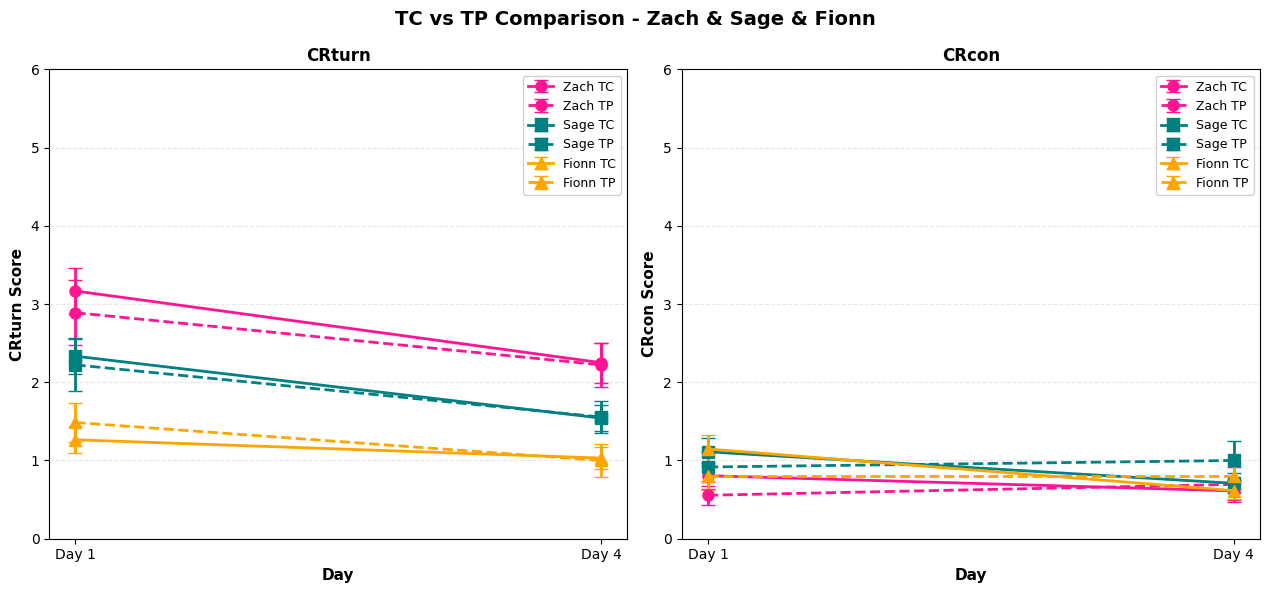

All plots generated successfully


In [77]:
# ============================================================================
# EXAMPLE 2: All three scorers - each with unique colors
# Zach: Blue/Pink, Sage: Green/Purple, Fionn: Orange/Purple
# ============================================================================
create_day_comparison_lines(
    tc_troupes=['TC-6', 'TC-7'],
    tp_troupes=['TP-3', 'TP-4'],
    scorers=['Zach', 'Sage', 'Fionn'],
    behaviors=['CRturn', 'CRcon'],
    days=[1, 4],
    figsize=(8, 6),
    SAVE=False,
    turn_ylim=6.0,
    con_ylim=6
)

print("All plots generated successfully")

## 

## Function call to create behavior summary table

In [78]:
# ============================================================================
# UPDATED EXAMPLE SUMMARY TABLE CALLS
# ============================================================================

# Example 1: Compare all scorers with TC/TP separated
combined_summaries = []
for scorer_name in ['Zach', 'Sage', 'Fionn']:
    summary = create_behavior_summary_table(
        scorer=scorer_name,
        tc_troupes=['TC-6', 'TC-7'],
        tp_troupes=['TP-3', 'TP-4'],
        behaviors=['CRturn', 'CRcon'],
        days=[1, 4],
        error_type='95CI'
    )
    combined_summaries.append(summary)

# Combine all scorer summaries into one dataframe
all_scorers_summary = pd.concat(combined_summaries, ignore_index=True)
print("\nAll Scorers Summary (TC vs TP):")
print(all_scorers_summary)


# # Example 4: View in a more readable format - pivot table style
# print("\n=== CRturn by Scorer and Group ===")
# crturn_data = all_scorers_summary[all_scorers_summary['Behavior'] == 'CRturn']
# for day in [1, 4]:
#     print(f"\nDay {day}:")
#     day_data = crturn_data[crturn_data['Day'] == day][['Scorer', 'Group', 'Mean', '95% CI', 'N']]
#     print(day_data.to_string(index=False))


All Scorers Summary (TC vs TP):
   Scorer Group Behavior  Day  Mean    SEM  95% CI   N   Std
0    Zach    TC    CRcon    1  0.81  0.165   0.329  72  1.40
1    Zach    TC    CRcon    4  0.61  0.115   0.228  72  0.97
2    Zach    TP    CRcon    1  0.56  0.122   0.249  36  0.73
3    Zach    TP    CRcon    4  0.69  0.221   0.449  36  1.33
4    Zach    TC   CRturn    1  3.17  0.289   0.576  72  2.45
5    Zach    TC   CRturn    4  2.25  0.257   0.512  72  2.18
6    Zach    TP   CRturn    1  2.89  0.416   0.844  36  2.49
7    Zach    TP   CRturn    4  2.22  0.285   0.578  36  1.71
8    Sage    TC    CRcon    1  1.11  0.178   0.354  72  1.51
9    Sage    TC    CRcon    4  0.71  0.127   0.254  72  1.08
10   Sage    TP    CRcon    1  0.92  0.188   0.383  36  1.13
11   Sage    TP    CRcon    4  1.00  0.252   0.512  36  1.51
12   Sage    TC   CRturn    1  2.33  0.229   0.457  72  1.94
13   Sage    TC   CRturn    4  1.54  0.168   0.335  72  1.42
14   Sage    TP   CRturn    1  2.22  0.329   0.668  

### NOTES AND TBD:
- Figure out why Fionn data has 68 and not 72 like everyone else
- Fix the double regions issue for that one video